# Part 2.3: Creative AI – QuickDraw Birthday Cake Sketch Generation

This notebook trains a DCGAN on the Quick, Draw! `birthday cake` category in order to generate synthetic hand-drawn birthday cake sketches.

## Objectives
- Download and explore the QuickDraw `birthday cake` bitmap dataset.
- Train a DCGAN on 28×28 grayscale sketches.
- Track generator and discriminator losses over training.
- Generate fake birthday cake sketches and compare them with real sketches.
- Reflect on the quality and limitations of the generated drawings.

In [1]:
import os
import sys
import random
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlretrieve

import torch
from torch.utils.data import DataLoader, TensorDataset

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

from src.image_dcgan_models import DCGANGenerator28x28, DCGANDiscriminator28x28
from src.training_loops import train_dcgan_images

quickdraw_root = os.path.join(project_root, "data", "quickdraw")
os.makedirs(quickdraw_root, exist_ok=True)

print("Project root:", project_root)
print("QuickDraw root:", quickdraw_root)

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Project root: /Users/indhureddy/Documents/gan-case-study-7PAM2016
QuickDraw root: /Users/indhureddy/Documents/gan-case-study-7PAM2016/data/quickdraw
Device: cpu


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

quickdraw_path = "/Users/indhureddy/Documents/gan-case-study-7PAM2016/data/quickdraw/birthday_cake.npy"

if not os.path.exists(quickdraw_path):
    raise FileNotFoundError(f"File not found: {quickdraw_path}")

sketches = np.load(quickdraw_path)
print("Shape:", sketches.shape)
print("Dtype:", sketches.dtype)
print("Min pixel value:", sketches.min())
print("Max pixel value:", sketches.max())

sketches_reshaped = sketches.reshape(-1, 28, 28)
print("Reshaped shape:", sketches_reshaped.shape)

Shape: (144982, 784)
Dtype: uint8
Min pixel value: 0
Max pixel value: 255
Reshaped shape: (144982, 28, 28)


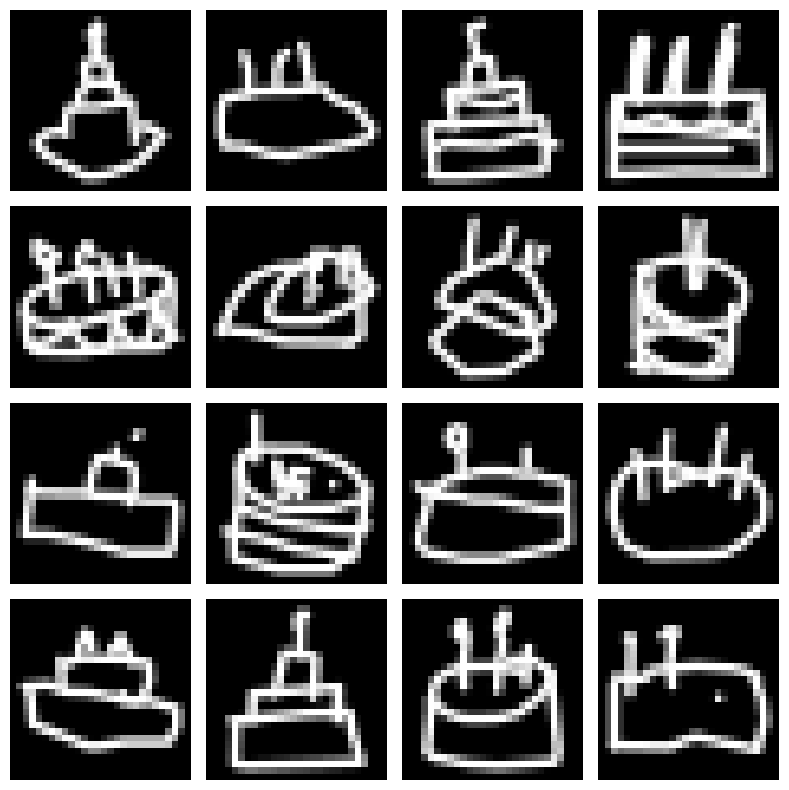

In [3]:
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(sketches_reshaped[i], cmap="gray")
    ax.axis("off")
plt.tight_layout()
plt.show()

# Preprocessing

In [4]:
sketches = sketches_reshaped.astype("float32")
sketches = (sketches / 127.5) - 1.0
sketches = np.expand_dims(sketches, axis=-1)

print("Processed shape:", sketches.shape)
print("Processed min:", sketches.min())
print("Processed max:", sketches.max())

Processed shape: (144982, 28, 28, 1)
Processed min: -1.0
Processed max: 1.0


# TensorFlow dataset

In [6]:
%pip install tensorflow

  Using cached tensorflow-2.21.0-cp312-cp312-macosx_12_0_arm64.whl.metadata (4.4 kB)
  Using cached absl_py-2.5.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-1-py2.py3-none-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.35.1-cp310-abi3-macosx_10_9_universal2.whl.metadata (595 bytes)
  Using cached wrapt-2.2.2-cp312-cp312-macosx_11_0_arm64.whl.metadata (7.4 kB)
  Using cached keras-3.15.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached h5py-3.14.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (2.7 kB)
  Using cached ml_dtypes-0.5.4-cp312-cp312-macosx_10_13_universal2.whl.metadata (8.9 kB)
  Using cached rich

In [7]:
import tensorflow as tf

BATCH_SIZE = 128
BUFFER_SIZE = sketches.shape[0]

train_dataset = tf.data.Dataset.from_tensor_slices(sketches)
train_dataset = train_dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE, drop_remainder=True)

print(train_dataset)

<_BatchDataset element_spec=TensorSpec(shape=(128, 28, 28, 1), dtype=tf.float32, name=None)>


Models

In [8]:
from tensorflow.keras import layers

LATENT_DIM = 100

def build_generator():
    model = tf.keras.Sequential([
        layers.Input(shape=(LATENT_DIM,)),
        layers.Dense(7 * 7 * 256, use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Reshape((7, 7, 256)),

        layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh')
    ])
    return model

def build_discriminator():
    model = tf.keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(1)
    ])
    return model

generator = build_generator()
discriminator = build_discriminator()

In [9]:
noise = tf.random.normal([1, LATENT_DIM])
generated_image = generator(noise, training=False)

print("Generated image shape:", generated_image.shape)

decision = discriminator(generated_image)
print("Discriminator output shape:", decision.shape)

Generated image shape: (1, 28, 28, 1)
Discriminator output shape: (1, 1)


Losses and optimizers

In [10]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

Training step

In [11]:
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, LATENT_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

Training loop with sample images

Epoch 1, Gen Loss: 1.2531, Disc Loss: 0.8900, Time: 237.21 sec


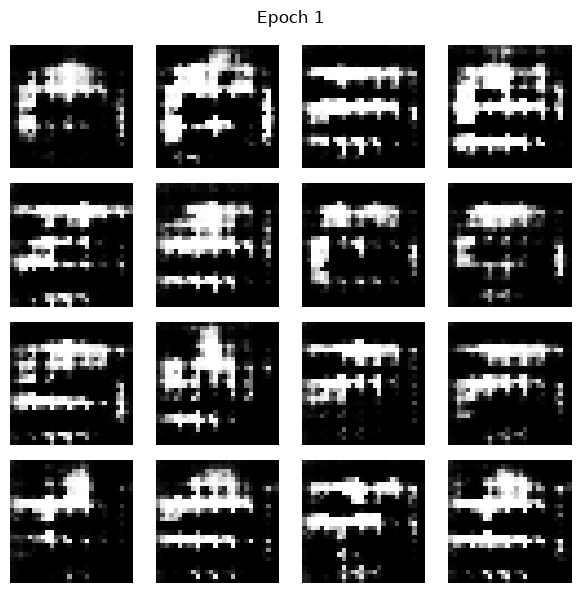

Epoch 2, Gen Loss: 2.5814, Disc Loss: 0.3028, Time: 255.19 sec


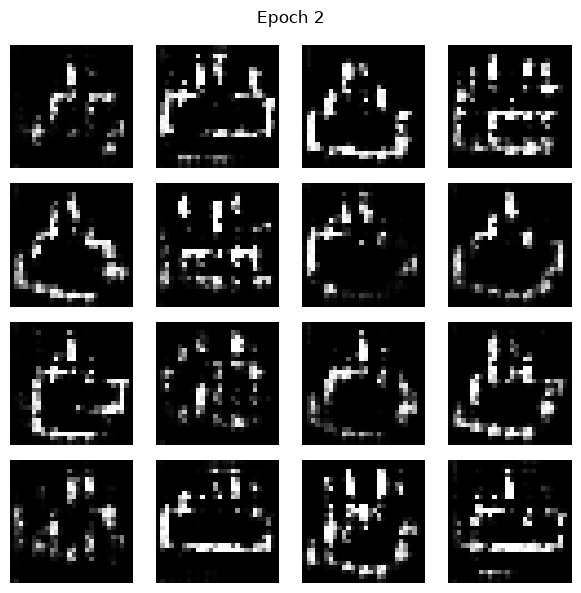

Epoch 3, Gen Loss: 1.7815, Disc Loss: 0.7437, Time: 275.01 sec
Epoch 4, Gen Loss: 1.9168, Disc Loss: 0.8576, Time: 278.15 sec


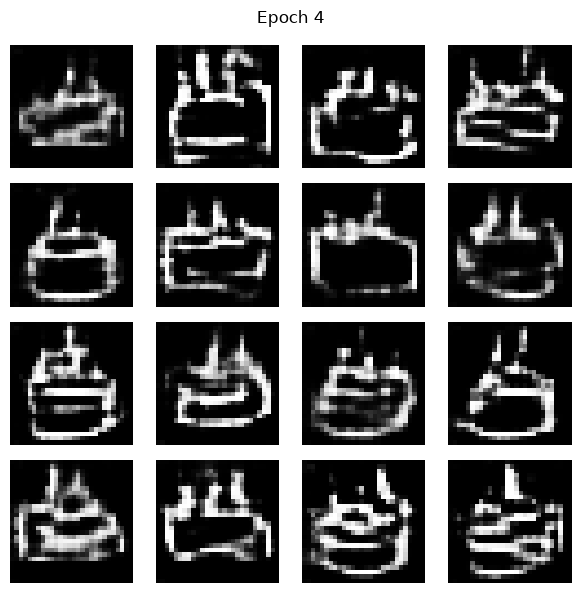

Epoch 5, Gen Loss: 1.7174, Disc Loss: 0.7965, Time: 270.54 sec


In [12]:
import matplotlib.pyplot as plt
import time

EPOCHS = 5  # start small on CPU
num_examples_to_generate = 16
seed = tf.random.normal([num_examples_to_generate, LATENT_DIM])

def generate_and_show_images(model, epoch, test_input):
    predictions = model(test_input, training=False)

    fig = plt.figure(figsize=(6, 6))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        img = (predictions[i, :, :, 0] + 1.0) / 2.0
        plt.imshow(img, cmap='gray')
        plt.axis('off')

    plt.suptitle(f"Epoch {epoch}")
    plt.tight_layout()
    plt.show()

def train(dataset, epochs):
    for epoch in range(epochs):
        start = time.time()

        for image_batch in dataset:
            gen_loss, disc_loss = train_step(image_batch)

        print(
            f"Epoch {epoch+1}, "
            f"Gen Loss: {gen_loss:.4f}, "
            f"Disc Loss: {disc_loss:.4f}, "
            f"Time: {time.time()-start:.2f} sec"
        )

        if (epoch + 1) % 2 == 0 or epoch == 0:
            generate_and_show_images(generator, epoch + 1, seed)

train(train_dataset, EPOCHS)

Fake vs real figure 

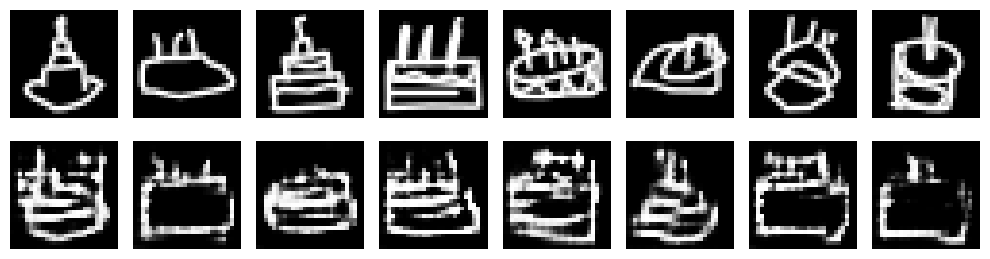

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Real samples
fig, axes = plt.subplots(2, 8, figsize=(10, 3))
for i in range(8):
    axes[0, i].imshow(sketches_reshaped[i], cmap="gray")
    axes[0, i].axis("off")
# Fake samples from the trained generator
noise = tf.random.normal([8, LATENT_DIM])
fake_imgs = generator(noise, training=False)
fake_imgs = (fake_imgs.numpy()[:, :, :, 0] + 1.0) / 2.0

for i in range(8):
    axes[1, i].imshow(fake_imgs[i], cmap="gray")
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Real", fontsize=10)
axes[1, 0].set_ylabel("Fake", fontsize=10)
plt.tight_layout()
plt.show()

In [14]:
# Generate fake samples
num_fake = 1000
noise = tf.random.normal([num_fake, LATENT_DIM])
fake_imgs = generator(noise, training=False).numpy()

# Convert fake images from [-1, 1] to [0, 1]
fake_imgs_01 = (fake_imgs + 1.0) / 2.0

# Convert real images from [-1, 1] to [0, 1]
real_imgs_01 = (sketches[:num_fake] + 1.0) / 2.0

print("Real mean pixel intensity:", real_imgs_01.mean())
print("Fake mean pixel intensity:", fake_imgs_01.mean())

print("Real pixel std:", real_imgs_01.std())
print("Fake pixel std:", fake_imgs_01.std())

Real mean pixel intensity: 0.19810252
Fake mean pixel intensity: 0.20397912
Real pixel std: 0.3443976
Fake pixel std: 0.34245497


## Part 2.3 Summary and Evaluation

For the Creative AI experiment, a DCGAN was trained on the QuickDraw **birthday cake** category (144,982 sketches at 28×28 resolution). The raw 784-dimensional vectors were reshaped into 28×28 grayscale images and normalised to the range [-1, 1], then fed into a ConvNet-based generator–discriminator pair implemented in TensorFlow. Training on CPU for 5 epochs produced stable generator and discriminator losses and progressively clearer cake-like outputs. 

Qualitatively, the generated images evolved from noisy blobs in early epochs to recognisable cakes with candles by epoch 4, as seen in the training samples, although some outputs remain blurry or incomplete. A side-by-side panel of real QuickDraw sketches versus generated cakes shows that the model captures the main structure of the class (cake base plus vertical candle strokes), but fine details and variety could be improved with longer training or further tuning. 

As a simple quantitative check, the mean pixel intensity and standard deviation were compared between 1,000 real sketches and 1,000 generated samples, after rescaling pixels to the [0, 1] range. Real images had mean intensity 0.198 and standard deviation 0.344, while generated images had mean 0.204 and standard deviation 0.342, indicating that the DCGAN has learned a very similar overall brightness and contrast distribution to the real data. This rough statistical agreement supports the visual impression that the generator approximates the real sketch distribution, even though a full Frechet Inception Distance evaluation was not performed due to CPU constraints. 